<a href="https://colab.research.google.com/github/danielarruda1000/geo_visao_comp/blob/main/GEO_VISAO_PROJ_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Questão 1**: Encontre o par de câmeras usando nessas imagens usando correspondência 3d 2d

**Questão 2**: faça a reconstrução 3d de um ponto (não usado na questão 1). Ou seja, vc vai definir um ponto em cada imagem e fazer a reconstrução do ponto 3d associado usando as câmeras

In [1]:
from IPython.display import Image
import matplotlib.pyplot as plt

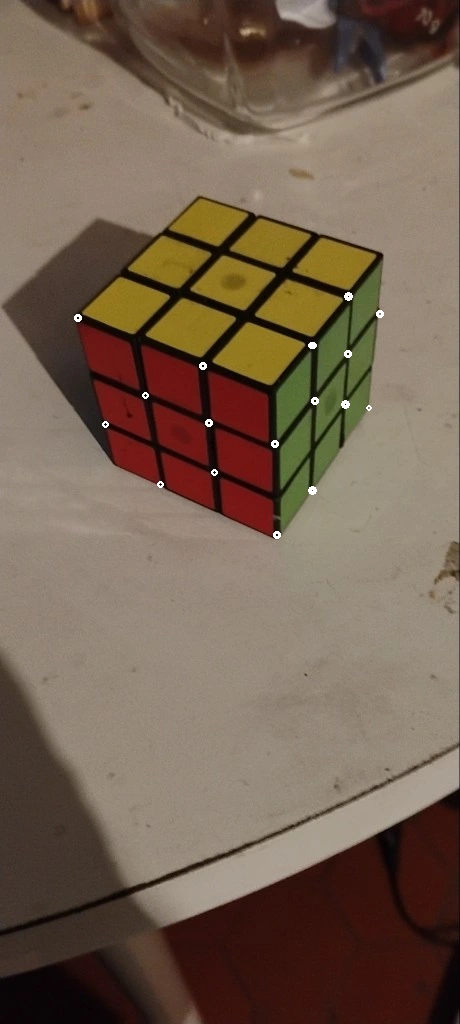

In [2]:
Image("cubo_1_marcações.png")

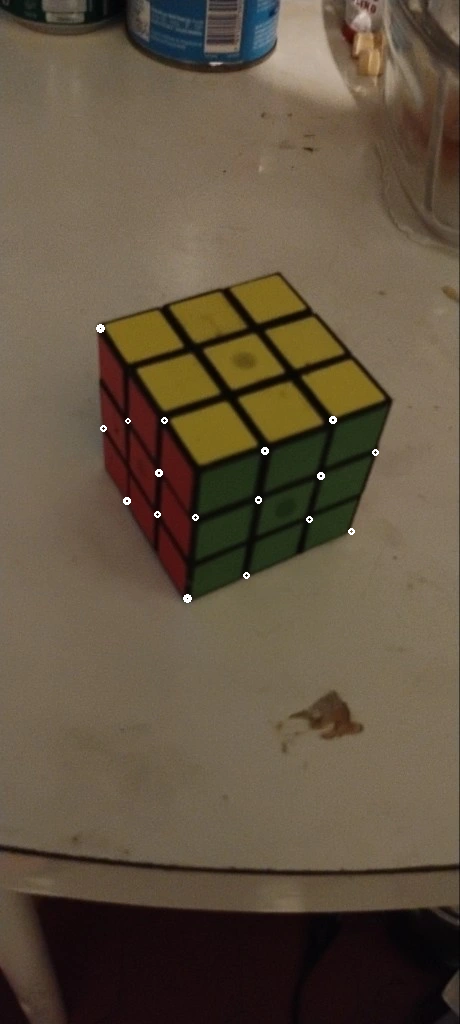

In [3]:
Image("cubo_2_marcações.png")

# Questão 1) Encontrar o par de cameras

In [4]:
import numpy as np

def achar_matriz_p_camera(points_3d, points_2d):

    n = points_3d.shape[0]
    A = []

    for i in range(n):
        X, Y, Z = points_3d[i]
        u, v = points_2d[i]

        A.append([ X, Y, Z, 1,   0, 0, 0, 0,   -u*X, -u*Y, -u*Z, -u ])
        A.append([ 0, 0, 0, 0,   X, Y, Z, 1,   -v*X, -v*Y, -v*Z, -v ])

    A = np.array(A)

    U, S, Vt = np.linalg.svd(A)
    P = Vt[-1].reshape(3, 4)

    return P / P[-1, -1]

In [5]:
# Pontos 3D
points_3d = np.array([
  (0,0,0),
  (0,0,2),
  # Lado verde
  (1,0,0),
  (1,0,2),
  (1,0,3),
  (2,0,1),
  (2,0,2),
  (2,0,3),
  (3,0,0),
  (3,0,2),
  # Lado Vermelho
  (0,1,1),
  (0,1,2),
  (0,1,3),
  (0,2,0),
  (0,2,2),
  (0,3,1),
  (0,3,3)

], dtype=float)

# Pontos 2D da foto 1
points_2d_foto_1 = np.array([
  (274, 536),
  (274, 443),
  # Lado verde
  (311, 490),
  (314, 400),
  (312, 344),
  (345, 405),
  (348, 353),
  (348, 297),
  (368, 407),
  (379, 310),
  # Lado Vermelho
  (214, 471),
  (208, 422),
  (203, 367),
  (164, 486),
  (145, 394),
  (105, 425),
  (77, 317)

], dtype=float)


# Pontos 2D da foto 2
points_2d_foto_2 = np.array([
  (187, 599),
  (194, 517),
  # Lado verde
  (246, 575),
  (258, 498),
  (263, 449),
  (309, 519),
  (312, 475),
  (333, 420),
  (350, 532),
  (375, 452),
  # Lado Vermelho
  (158, 513),
  (158, 473),
  (161, 418),
  (127, 501),
  (128, 420),
  (103, 429),
  (100, 327)

], dtype=float)


P1 = achar_matriz_p_camera(points_3d, points_2d_foto_1)
P2 = achar_matriz_p_camera(points_3d, points_2d_foto_2)

print("Matriz de câmera P1:\n", P1)
print()
print("Matrix de câmera P2:\n", P2)

Matriz de câmera P1:
 [[ 4.46276403e+01 -5.08959932e+01 -1.83556498e+01  2.75762047e+02]
 [-2.81238148e+01 -1.13885091e+01 -7.26205618e+01  5.36191050e+02]
 [ 3.62624071e-02  2.66538449e-02 -6.26641105e-02  1.00000000e+00]]

Matrix de câmera P2:
 [[ 6.09465486e+01 -2.26097839e+01 -8.95420446e+00  1.87080824e+02]
 [-1.09976797e+01 -2.38997878e+01 -7.15818677e+01  5.98611994e+02]
 [ 2.00253459e-02  4.50595070e-02 -6.21333494e-02  1.00000000e+00]]


In [56]:
def aplicar_p(P, points_3d, points_2d_expectativa):

  ponto_rp2 = P @ points_3d

  u = round(ponto_rp2[0] / ponto_rp2[2])
  v = round(ponto_rp2[1] / ponto_rp2[2])

  ponto_projetado = np.array([u, v])
  print('\nPonto 3D:       ', points_3d[0:3])
  print('Ponto Esperado: ', points_2d_expectativa)
  print('Ponto Projetado:', ponto_projetado)

In [57]:
print('Foto 1')
# Foto 1 no ponto (0,0,1) | Expectativa (276, 495)
aplicar_p(P1, np.array([0,0,1, 1]), np.array([276, 495]))

# Foto 1 no ponto (1,0,1) | Expectativa (311, 449)
aplicar_p(P1, np.array([1,0,1, 1]), np.array([311, 449]))

print('\nFoto 2')
# Foto 2 no ponto (0,0,1) | Expectativa (191, 561)
aplicar_p(P2, np.array([0,0,1, 1]), np.array([191, 561]))

# Foto 2 no ponto (1,0,1) | Expectativa (251, 541)
aplicar_p(P2, np.array([1,0,1, 1]), np.array([251, 541]))


Foto 1

Ponto 3D:        [0 0 1]
Ponto Esperado:  [276 495]
Ponto Projetado: [275 495]

Ponto 3D:        [1 0 1]
Ponto Esperado:  [311 449]
Ponto Projetado: [310 447]

Foto 2

Ponto 3D:        [0 0 1]
Ponto Esperado:  [191 561]
Ponto Projetado: [190 562]

Ponto 3D:        [1 0 1]
Ponto Esperado:  [251 541]
Ponto Projetado: [250 539]


# Questão 2

In [62]:
def triangular_duas_views(P1, x1, P2, x2):

    u1, v1 = x1 # Pontos na foto 1
    u2, v2 = x2 # Pontos na foto 2

    A = np.vstack([
        u1 * P1[2, :] - P1[0, :],
        v1 * P1[2, :] - P1[1, :],
        u2 * P2[2, :] - P2[0, :],
        v2 * P2[2, :] - P2[1, :]
    ])

    _, _, Vt = np.linalg.svd(A)
    Xh = Vt[-1]

    X = Xh[:3] / Xh[3]

    return X, Xh

In [64]:
# Ponto esperado 3D (0,0,3)
# Foto 1 = (271, 389)
# Foto 2 = (198, 470)

X, Xh = triangular_duas_views(P1, (271,389), P2, (198,470))

print("Ponto 3D:", X)

Ponto 3D: [0.02832184 0.02411383 3.00677484]
